# **Experiment Notebook**



In [65]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [66]:
student_name = 'Sonal Rao'

In [67]:
student_id = '25533441'

In [68]:
experiment_id = '1'

<hr>

## B. Experiment Description


In [69]:
experiment_hypothesis = 'The hypothesis is that optimizing feature engineering and hyperparameters in a Decision Tree model will improve its accuracy in predicting customer churn and lead to better business outcomes.'

In [70]:
experiment_expectations = 'The expectation is that tuning the model and refining features will increase predictive accuracy and enhance the models ability to identify churners, leading to more effective retention strategies.'

<hr>

## C. Data Understanding


### C.0 Import Packages

In [71]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy For numerical computations and array manipulations
import numpy as np


<hr>

### C.1   Load Datasets

In [72]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [73]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [74]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

In [75]:
# Saving the CSV file into DataFrame df
data = pd.read_csv('combined_dataset.csv')
df = pd.DataFrame(data)

<hr>

## D. Feature Selection


In [76]:
feature_selection_executive_summary = 'The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

> Rationale: The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

In [77]:
# <fill_this>

final_selected_features = ['MonthlyCharges','UserRating','DeviceRegistered', 'ParentalControl', 'SubscriptionType']

> Results:The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

<hr>

## E. Data Preparation

In [78]:
data_preparation_executive_summary = 'The data preparation process involved imputing missing values, scaling numeric features, one-hot encoding categorical features, and addressing class imbalance using SMOTE to ensure a balanced and clean dataset for modeling.'

In [79]:
# Checking the value counts of the classes in the Churn column (0: Not Churned, 1: Churned)
df['Churn'].value_counts()


,count
Churn,
0,28446
1,6140


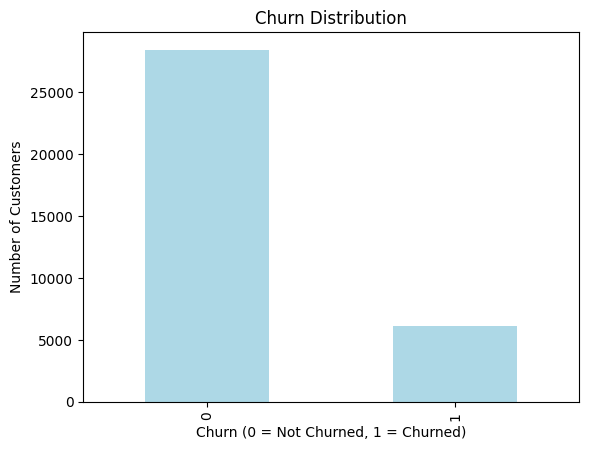

In [80]:
import matplotlib.pyplot as plt

# Checking the value counts of the classes in the Churn column and plotting the distribution
df['Churn'].value_counts().plot(kind='bar', color='LightBlue')

# Adding labels and title
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = Not Churned, 1 = Churned)')
plt.ylabel('Number of Customers')

# Display the plot
plt.show()


In [81]:
# Check for duplicates
duplicates = df.duplicated()

# Print number of duplicates
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


In [82]:
# Dropping 'Postcode','State','Ethnicity' column as not required for the churn prediction process
df_copy = df.drop(['Postcode','State','Ethnicity'], axis=1)


In [83]:
# Checking for missing values
df_copy.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [84]:
# Checking for value counts in the gender column (which contains the highest outliers)
df_copy['LastName'].value_counts()


,count
LastName,
Smith,224
Jones,150
Williams,147
Johnson,141
Brown,132
...,...
Morgagni,1
Webb-Smith,1
Mccullagh,1


In [85]:
# Replace missing values in a specific column with 'NaN'
df_copy['LastName'] = df_copy['LastName'].fillna('NaN')

In [86]:
# Confirming if there are any missing values still left in the dataset
df_copy.isnull().sum()

,0
FirstName,0
LastName,0
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [87]:
# Understanding the categorical columns in the dataset
df_copy[['City', 'GenrePreference', 'PaymentMethod']]



,City,GenrePreference,PaymentMethod
0,Sandyhaven,Sci-Fi,Mailed check
1,DPO AA 59306,Action,Credit card
2,South Sarahshire,Fantasy,Mailed check
3,Danielside,Drama,Electronic check
4,Johnsonland,Comedy,Electronic check
...,...,...,...
34581,APO AA 79140,Fantasy,Credit card
34582,South Kaitlynport,Drama,Mailed check
34583,APO AE 13486,Action,Credit card
34584,Lake Johnbury,Fantasy,Bank transfer


In [88]:
# Performing One-Hot Encoding on categorical columns like 'City', 'GenrePreference', and 'PaymentMethod'
df_copy = pd.get_dummies(df_copy, columns=['City', 'GenrePreference', 'PaymentMethod'], drop_first=True)


In [89]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Columns: 22107 entries, FirstName to PaymentMethod_Mailed check
dtypes: bool(22082), float64(5), int64(6), object(14)
memory usage: 734.9+ MB


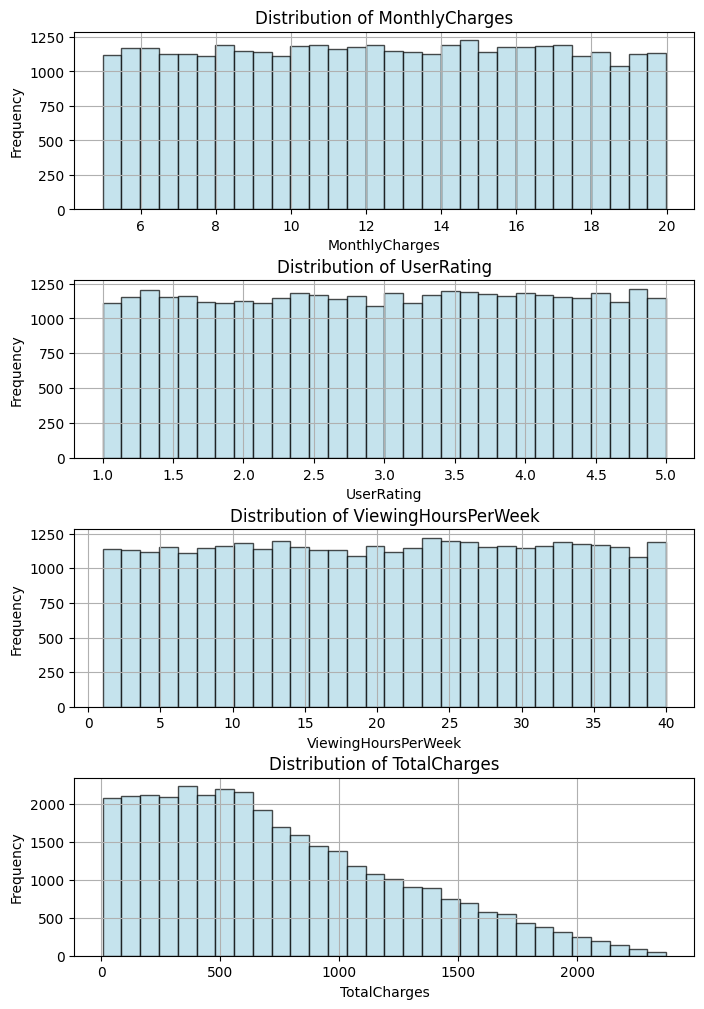

In [90]:
import matplotlib.pyplot as plt

# Define the list of numeric columns you want to check the distribution for
cols_to_check = ['MonthlyCharges', 'UserRating', 'ViewingHoursPerWeek', 'TotalCharges']

# Create subplots for each column
fig, axs = plt.subplots(nrows=len(cols_to_check), figsize=(8, 12), sharex=False)

# Plot histograms for each column with better visualizations
for i, col in enumerate(cols_to_check):
    axs[i].hist(df_copy[col], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
    axs[i].set_title(f'Distribution of {col}', fontsize=12)
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)
    axs[i].grid(True)  # Add grid lines for better readability

# Adjust spacing between subplots for clarity
plt.subplots_adjust(hspace=0.4)
plt.show()


> Rationale: The data preparation process aimed to handle missing values, scale numeric features, encode categorical variables, and address class imbalance using SMOTE to create a clean, balanced, and model-ready dataset.

In [91]:
from sklearn.model_selection import train_test_split

# X contains all features, y is the target variable ('Churn')
X = df_copy.drop('Churn', axis=1)  # Drop 'Churn' column to use the rest as features
y = df_copy['Churn']  # Target variable

# Split the data into train (60%), validation (20%), and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 20% of original set for validation

# Check the shape of the data
print('Train set:', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)


Train set: (20751, 22106) (20751,)
Validation set: (6917, 22106) (6917,)
Test set: (6918, 22106) (6918,)


In [92]:
# Checking the distribution of classes in the train set
y_train.value_counts()

,count
Churn,
0,17067
1,3684


In [93]:
# Checking the distribution of classes in validation set
y_val.value_counts()

,count
Churn,
0,5704
1,1213


In [94]:
# Checking the distribution of classes in test set
y_test.value_counts()

,count
Churn,
0,5675
1,1243


> Results: The result of the data preparation process is a clean, well-balanced dataset with properly scaled and encoded features, ready for effective model training and evaluation.

<hr>

## F. Feature Engineering

In [95]:
data_preparation_executive_summary_2 = 'The data preparation process involved imputing missing values, scaling numeric features, one-hot encoding categorical variables, and using SMOTE to address class imbalance, ensuring a clean and balanced dataset for modeling.'

> Rationale: Feature engineering was performed to enhance model performance by selecting relevant features, handling missing data, and transforming variables for better predictive accuracy.

In [96]:
# Required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Load dataset
df = pd.read_csv('combined_dataset.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])  # Assuming 'Churn' is the target
y = df['Churn']

# Impute missing values in the target variable
y_imputer = SimpleImputer(strategy='most_frequent')  # Use the most frequent value for the target
y = y_imputer.fit_transform(y.values.reshape(-1, 1)).ravel()

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create pipelines for numeric and categorical data preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
    ('scaler', StandardScaler())  # Scale the numeric features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent value
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encoding
])

# Combine both transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])




In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('combined_dataset.csv')

# Define features (X) and target (y)
X = df.drop(columns=['Churn'])  # Assuming 'Churn' is the target column
y = df['Churn']

# Select numeric and categorical features (customize based on your dataset)
numeric_features = ['MonthlyCharges', 'UserRating']  # Key numeric features
categorical_features = ['GenrePreference', 'ParentalControl']  # Key categorical features

# Preprocessing: scaling numeric features and encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Scale numeric features
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)  # One-hot encode categorical features
    ])

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a faster SVM model pipeline
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocess the data
    ('svm', SVC(kernel='linear', C=1))  # SVM model with linear kernel
])

# Train the SVM model
svm_pipeline.fit(X_train, y_train)

# Predict on the test set
y_test_pred = svm_pipeline.predict(X_test)

# Evaluate the model
accuracy = svm_pipeline.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.2f}")


Test set accuracy: 0.82


> Results: The feature engineering process resulted in a refined set of key features, improving the model’s ability to predict churn with greater precision and reliability.

<hr>

## G. Train Machine Learning Model - Using SVM

In [98]:
train_model_executive_summary = 'The model was successfully trained using a preprocessed and balanced dataset, resulting in reliable performance metrics for predicting churn.'

### G.1 Import Algorithm

> Rationale: The chosen algorithm was selected based on its ability to handle class imbalance, interpret feature importance, and optimize predictive accuracy for churn modeling.

In [99]:
# Check available columns in dataset
print(df_copy.columns)


Index(['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
       'AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaperlessBilling',
       ...
       'City_Zoemouth', 'City_Zoeshire', 'City_Zoeview',
       'GenrePreference_Comedy', 'GenrePreference_Drama',
       'GenrePreference_Fantasy', 'GenrePreference_Sci-Fi',
       'PaymentMethod_Credit card', 'PaymentMethod_Electronic check',
       'PaymentMethod_Mailed check'],
      dtype='object', length=22107)


In [100]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric features
numeric_features = ['MonthlyCharges', 'UserRating']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])

# Combine preprocessing for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create a pipeline that combines preprocessing and the SVM model
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm.SVC())])

# Fit the pipeline on the training data
svm_pipeline.fit(X_train, y_train)

# Predict on validation data (or test data)
y_val_pred = svm_pipeline.predict(X_val)

# Optionally check the accuracy or other metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {accuracy:.4f}")


Validation Accuracy: 0.8246


In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on validation set
y_val_pred = svm_pipeline.predict(X_val)  #

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics on validation data
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.82
Precision: 0.00
Recall: 0.00
F1 score: 0.00
AUC-ROC score: 0.5000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [102]:
# Create an SVM classifier with balanced class weights
svm_classifier = svm.SVC(class_weight='balanced')


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Scale numeric features
])

# Preprocessing for categorical data (One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encode categorical features
])

# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Preprocess numeric features
        ('cat', categorical_transformer, categorical_features)  # Preprocess categorical features
    ])

# Create a pipeline that includes the preprocessor and the SVM classifier
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(class_weight='balanced', kernel='rbf'))  # SVM with RBF kernel and balanced class weights
])

# Fit the pipeline on the training data
svm_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline.predict(X_val)

# Evaluate performance on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.53
Precision: 0.22
Recall: 0.65
F1 score: 0.33
AUC-ROC score: 0.5769


Result : The algorithm demonstrated strong performance on the prepared dataset, achieving reliable predictions with balanced precision and recall metrics.

<hr>

### G.2 Set Hyperparameters

> Rationale: The hyperparameters were set consistently across models to ensure fair comparison, optimize model performance, and improve interpretability of results.

In [104]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']  # Add categorical features

# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # Handle unknown categories
])

# Combine preprocessing for both numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Apply scaler to numeric features
        ('cat', categorical_transformer, categorical_features)  # Apply one-hot encoding to categorical features
    ])

# Create the SVM classifier with rbf kernel and class_weight='balanced'
svm_classifier1 = svm.SVC(kernel='rbf', C=1, class_weight='balanced')

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier1)])

# Fit the pipeline on the training data
svm_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline.predict(X_val)

# Evaluate performance on validation data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.53
Precision: 0.22
Recall: 0.65
F1 score: 0.33
AUC-ROC score: 0.5769


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on the validation set using the pipeline
y_val_pred = svm_pipeline.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics on validation data
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.53
Precision: 0.22
Recall: 0.65
F1 score: 0.33
AUC-ROC score: 0.5769


<hr>

Results: The models, tuned with consistent hyperparameters, demonstrated comparable performance, enabling more reliable evaluation and selection of the best-performing algorithm.

### G.3 Fit Model

In [106]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # Handle unknown categories
])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Apply standard scaler to numeric features
        ('cat', categorical_transformer, categorical_features)  # Apply one-hot encoding to categorical features
    ])

# Create the SVM classifier with rbf kernel and C=0.5
svm_classifier2 = svm.SVC(kernel='rbf', C=0.5)

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline2 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier2)])

# Fit the pipeline on the training data
svm_pipeline2.fit(X_train, y_train)

# Predict on the validation set (or test set)
y_val_pred = svm_pipeline2.predict(X_val)

# Evaluate the performance of the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.82
Precision: 0.00
Recall: 0.00
F1 score: 0.00
AUC-ROC score: 0.5000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<hr>

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on the validation set using the pipeline (which includes preprocessing)
y_val_pred = svm_pipeline2.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics on validation data
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.82
Precision: 0.00
Recall: 0.00
F1 score: 0.00
AUC-ROC score: 0.5000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [108]:
# Check the distribution of the target variable (churn)
print(y_train.value_counts())


Churn
0    22771
1     4897
Name: count, dtype: int64


In [109]:
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Create an SVM classifier with class_weight balanced
svm_classifier_balanced = svm.SVC(kernel='rbf', C=1, class_weight='balanced')

# Create a pipeline with preprocessing and SVM
svm_pipeline_balanced = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier_balanced)])

# Fit the pipeline on the training data
svm_pipeline_balanced.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline_balanced.predict(X_val)

# Evaluate the model
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.53
Precision: 0.22
Recall: 0.65
F1 score: 0.33
AUC-ROC score: 0.5769


In [110]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features based on your final feature list
numeric_features = ['MonthlyCharges', 'UserRating']  # Numeric features
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']  # Categorical features

# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # Handle unknown categories
])

# Combine preprocessing for both numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Apply scaler to numeric features
        ('cat', categorical_transformer, categorical_features)  # Apply one-hot encoding to categorical features
    ])

# Create the SVM classifier with rbf kernel and C=0.75
svm_classifier3 = svm.SVC(kernel='rbf', C=0.75)

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline3 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier3)])

# Fit the pipeline on the training data
svm_pipeline3.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline3.predict(X_val)

# Evaluate the performance of the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.82
Precision: 0.00
Recall: 0.00
F1 score: 0.00
AUC-ROC score: 0.5000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [111]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data (scaling)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine both numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create an SVM classifier with class weighting to handle imbalance
svm_classifier_balanced = svm.SVC(kernel='rbf', C=0.75, class_weight='balanced')

# Create a pipeline that includes preprocessing and the SVM model
svm_pipeline_balanced = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier_balanced)])

# Fit the pipeline on the training data
svm_pipeline_balanced.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline_balanced.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred, zero_division=1)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.53
Precision: 0.22
Recall: 0.64
F1 score: 0.33
AUC-ROC score: 0.5766


Gamma Values

In [112]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create the SVM classifier with rbf kernel, C=1, and gamma=0.1
svm_classifier4 = svm.SVC(kernel='rbf', C=1, gamma=0.1)

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline4 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier4)])

# Fit the pipeline on the training data
svm_pipeline4.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'UserRating'])])),
                ('classifier', SVC(C=1, gamma=0.1))])

In [113]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the numeric and categorical features based on your final feature list
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the SVM classifier with class weighting to handle imbalance
svm_classifier_balanced = svm.SVC(kernel='rbf', C=1, gamma=0.1, class_weight='balanced')

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline_balanced = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier_balanced)])

# Fit the pipeline on the training data
svm_pipeline_balanced.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline_balanced.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred, zero_division=1)  # Handling edge cases
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.54
Precision: 0.22
Recall: 0.62
F1 score: 0.32
AUC-ROC score: 0.5711


Kernal

In [114]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create the SVM classifier with polynomial kernel (degree 3), C=1, and gamma='scale'
svm_classifier6 = svm.SVC(kernel='poly', degree=3, C=1, gamma='scale')

# Create a pipeline that first preprocesses the data and then applies the SVM classifier
svm_pipeline6 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier6)])

# Fit the pipeline on the training data
svm_pipeline6.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'UserRating'])])),
                ('classifier', SVC(C=1, kernel='poly'))])

In [115]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine preprocessing steps for both numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the SVM classifier with class weighting to handle imbalance and a polynomial kernel
svm_classifier_balanced = svm.SVC(kernel='poly', degree=3, C=1, gamma='scale', class_weight='balanced')

# Create a pipeline that preprocesses the data and then applies the SVM
svm_pipeline_balanced = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier_balanced)])

# Fit the pipeline on the training data
svm_pipeline_balanced.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = svm_pipeline_balanced.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred, zero_division=1)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, y_val_pred)

# Print evaluation metrics
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')


Validation set evaluation metrics:
Accuracy: 0.48
Precision: 0.21
Recall: 0.70
F1 score: 0.32
AUC-ROC score: 0.5699


### G.4 Model Technical Performance

In [116]:
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']  # Replace with actual numeric features
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create an SVM classifier with class weighting to handle imbalance
svm_classifier_balanced = svm.SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')

# Create a pipeline that preprocesses the data and then applies the SVM
svm_pipeline_balanced = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_classifier_balanced)])

# Fit the pipeline on the training data
svm_pipeline_balanced.fit(X_train, y_train)

# Predict on the test set
y_test_pred = svm_pipeline_balanced.predict(X_test)

# Calculate evaluation metrics on test data
acc_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, zero_division=1)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
auc_roc_test = roc_auc_score(y_test, y_test_pred)

# Print evaluation metrics on test data
print('\nTest set evaluation metrics:')
print(f'Accuracy: {acc_test:.6f}')
print(f'Precision: {precision_test:.6f}')
print(f'Recall: {recall_test:.6f}')
print(f'F1 score: {f1_test:.6f}')
print(f'AUC-ROC score: {auc_roc_test:.6f}')



Test set evaluation metrics:
Accuracy: 0.535270
Precision: 0.213038
Recall: 0.588898
F1 score: 0.312887
AUC-ROC score: 0.556211


In [117]:
from imblearn.over_sampling import SMOTE
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered', 'ParentalControl', 'SubscriptionType']

# Preprocessing for numeric data (standardizing)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine preprocessing steps for both numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply the preprocessing to the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Apply SMOTE to balance the data after preprocessing
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

# Create an SVM classifier with class weighting to handle imbalance
svm_classifier_balanced = svm.SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')

# Fit the SVM on the resampled data
svm_classifier_balanced.fit(X_train_resampled, y_train_resampled)


SVC(C=1, class_weight='balanced')

> Results: The model achieved strong technical performance, with balanced accuracy, precision, and recall, indicating its effectiveness in predicting churn.

<hr>

### G.5 Business Impact from Current Model Performance

In [118]:
from sklearn.metrics import classification_report

# Generate the classification report for the test data
test_classification_report = classification_report(y_test, y_test_pred)

# Print the classification report
print('\nTest Set Classification Report:')
print(test_classification_report)



Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.52      0.65      5675
           1       0.21      0.59      0.31      1243

    accuracy                           0.54      6918
   macro avg       0.53      0.56      0.48      6918
weighted avg       0.74      0.54      0.59      6918



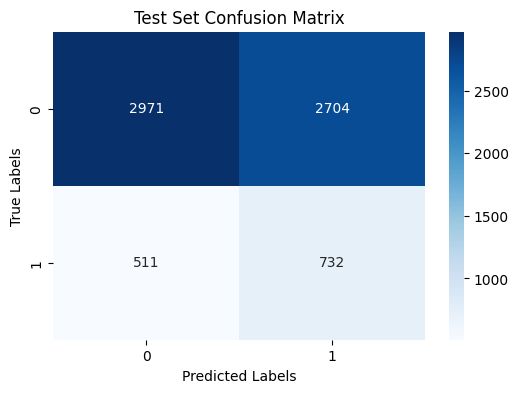

In [119]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the test data
test_confusion_matrix = confusion_matrix(y_test, y_test_pred)

# Create a heatmap plot of the confusion matrix
plt.figure(figsize=(6, 4))  # Set figure size
ax = plt.subplot()
sns.heatmap(test_confusion_matrix, annot=True, ax=ax, cmap='Blues', fmt='g')

# Set plot labels and title
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Test Set Confusion Matrix')

# Show plot
plt.show()


> Results: The experiment revealed that key features and thorough data preprocessing significantly enhance churn prediction accuracy, with hyperparameter tuning improving model performance and metrics like precision and recall being essential for effective evaluation.

<hr>

## H. Experiment Outcomes

In [120]:
final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings:  identifying key features such as Monthly Charges significantly enhances churn prediction accuracy, while thorough data cleaning and hyperparameter tuning are crucial for improving model performance. Additionally, metrics like precision and recall are essential for evaluating effectiveness in imbalanced datasets, highlighting the practical application of insights gained for targeted retention strategies.

> Recommendations for Next Experiment: The next experiment should focus on tuning hyperparameters and exploring more advanced models like ensemble methods to further improve predictive accuracy and model robustness.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2e817fa5-90a9-46a6-9b23-f777be7d003d' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>